# Q-Training Model (Unconstrained)

- stateless Q-learning  
- unconstrained training on a finite action grid  
- stronger convergence definition  
- continuous + grid benchmark comparison  
- training-path average learned weights  
- convergence speed (cumulative reward gap)  
- hyperparameter experiments  


In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from itertools import product
from scipy.optimize import minimize


In [41]:
# =========================================================
# 1. LOAD DATA — UNCONSTRAINED
# =========================================================

outdir = Path("project3_outputs")

# created in covMean notebook
mu_hat = np.load(outdir / "mu_hat.npy")
Sigma_hat = np.load(outdir / "Sigma_hat.npy")

Sigma_df = pd.read_csv(outdir / "covariance_matrix.csv", index_col=0)
asset_names = list(Sigma_df.columns)

gamma = 3.0

# ---------------------------------------------------------
# build a finite unconstrained action grid for tabular Q-learning
# true unconstrained optimization is continuous / unbounded,
# but tabular Q-learning needs a finite discrete action set.
# the range below is chosen to cover the current unconstrained optimum.
# ---------------------------------------------------------
step = 0.1
lower = -3.5
upper = 3.5
values = np.round(np.arange(lower, upper + step / 2, step), 10)

feasible_actions = []
for w1 in values:
    for w2 in values:
        w3 = round(1.0 - w1 - w2, 10)
        if lower - 1e-10 <= w3 <= upper + 1e-10:
            feasible_actions.append([
                round(w1, 10),
                round(w2, 10),
                round(w3, 10),
            ])

weights_df = pd.DataFrame(feasible_actions, columns=["w1", "w2", "w3"])
weights_df = weights_df.drop_duplicates().reset_index(drop=True)
action_grid = weights_df[["w1", "w2", "w3"]].values.astype(float)

# save the finite unconstrained grid for later reuse
unconstrained_action_path = outdir / "feasible_weights.csv"
weights_df.to_csv(unconstrained_action_path, index=False)

# ---------------------------------------------------------
# continuous unconstrained benchmark (closed-form solution)
# ---------------------------------------------------------
ones = np.ones(len(mu_hat))
Sigma_inv = np.linalg.inv(Sigma_hat)

lambda_star = (ones @ Sigma_inv @ mu_hat - gamma) / (ones @ Sigma_inv @ ones)
continuous_benchmark_weights = (1.0 / gamma) * (Sigma_inv @ (mu_hat - lambda_star * ones))

# optionally save benchmark for later reuse
pd.DataFrame({"weight": continuous_benchmark_weights}).to_csv(
    outdir / "unconstrained_benchmark_weights.csv", index=False
)

print("Assets:", asset_names)
print("mu_hat:", mu_hat)
print("Sigma_hat:\n", Sigma_hat)
print("Number of unconstrained feasible actions:", len(action_grid))
print(weights_df.head())
print("Saved unconstrained action grid to:", unconstrained_action_path)
print("Continuous unconstrained benchmark weights:", continuous_benchmark_weights)


Assets: ['SPY', 'IEF', 'GLD']
mu_hat: [ 0.00051575 -0.00024641  0.00032329]
Sigma_hat:
 [[1.08500755e-04 5.42930040e-06 1.54645268e-05]
 [5.42930040e-06 2.63825810e-05 1.88849140e-05]
 [1.54645268e-05 1.88849140e-05 8.14528009e-05]]
Number of unconstrained feasible actions: 3681
    w1   w2   w3
0 -3.5  1.0  3.5
1 -3.5  1.1  3.4
2 -3.5  1.2  3.3
3 -3.5  1.3  3.2
4 -3.5  1.4  3.1
Saved unconstrained action grid to: project3_outputs/feasible_weights.csv
Continuous unconstrained benchmark weights: [ 1.88578251 -3.23121701  2.3454345 ]


In [42]:
# =========================================================
# 2. REWARD + ENVIRONMENT
# =========================================================

def portfolio_return(weights, asset_returns):
    w = np.asarray(weights, dtype=float)
    r = np.asarray(asset_returns, dtype=float)

    if w.ndim != 1 or r.ndim != 1:
        raise ValueError("weights and asset_returns must both be 1D arrays")
    if w.shape[0] != r.shape[0]:
        raise ValueError("weights and asset_returns must have the same length")
    if not np.isfinite(w).all() or not np.isfinite(r).all():
        raise ValueError("weights and asset_returns must contain only finite values")

    return float(np.dot(w, r))


def reward_from_portfolio_return(portfolio_ret, gamma):
    if gamma < 0:
        raise ValueError("gamma must be non-negative")
    rp = float(portfolio_ret)
    return float(rp - 0.5 * gamma * (rp ** 2))


def mean_variance_reward(weights, asset_returns, gamma):
    rp = portfolio_return(weights, asset_returns)
    return reward_from_portfolio_return(rp, gamma)


def sample_one_return(mu, Sigma, rng):
    mu = np.asarray(mu, dtype=float)
    Sigma = np.asarray(Sigma, dtype=float)
    return rng.multivariate_normal(mean=mu, cov=Sigma)


In [43]:
# =========================================================
# 3. BENCHMARKS
# =========================================================

def utility_from_moments(weights, mu, Sigma, gamma):
    w = np.asarray(weights, dtype=float)
    mu = np.asarray(mu, dtype=float)
    Sigma = np.asarray(Sigma, dtype=float)

    mean_ = float(w @ mu)
    var_ = float(w @ Sigma @ w)
    utility_ = float(mean_ - 0.5 * gamma * var_)
    return {
        "mean": mean_,
        "variance": var_,
        "utility": utility_,
    }


def best_grid_benchmark(action_grid, mu, Sigma, gamma):
    utilities = []
    for w in action_grid:
        u = utility_from_moments(w, mu, Sigma, gamma)["utility"]
        utilities.append(u)

    utilities = np.array(utilities)
    idx = int(np.argmax(utilities))

    return {
        "best_idx": idx,
        "best_weights": action_grid[idx],
        "best_utility": float(utilities[idx]),
        "all_utilities": utilities,
    }


def build_benchmark_bundle(action_grid, mu, Sigma, gamma, continuous_weights=None):
    grid_bench = best_grid_benchmark(action_grid, mu, Sigma, gamma)

    bundle = {
        "grid_idx": grid_bench["best_idx"],
        "grid_weights": grid_bench["best_weights"],
        "grid_stats": utility_from_moments(grid_bench["best_weights"], mu, Sigma, gamma),
    }

    if continuous_weights is not None:
        bundle["continuous_weights"] = continuous_weights
        bundle["continuous_stats"] = utility_from_moments(continuous_weights, mu, Sigma, gamma)
    else:
        bundle["continuous_weights"] = None
        bundle["continuous_stats"] = None

    return bundle


In [44]:
# =========================================================
# 4. Q-LEARNING
# =========================================================

def epsilon_greedy_action(Q, epsilon, rng):
    if rng.random() < epsilon:
        return int(rng.integers(len(Q)))
    return int(np.argmax(Q))


def compute_recent_average_weights(weight_history, window):
    if len(weight_history) < window:
        return None
    arr = np.asarray(weight_history[-window:], dtype=float)
    return arr.mean(axis=0)


def train_q_learning(
        mu,
        Sigma,
        action_grid,
        gamma=3.0,
        alpha=0.05,
        beta=0.001,
        discount=0.95,
        max_iter=50000,
        convergence_window=2000,   # kept only for compatibility
        q_tol=1e-6,                # kept only for compatibility
        weight_tol=5e-3,
        benchmark_tol=0.15,        # kept only for compatibility
        grid_benchmark_weights=None,
        seed=42,
        verbose=False
):
    """
    Stateless Q-learning:
        Q(a_t) <- Q(a_t) + alpha * [reward + discount * max_a' Q(a') - Q(a_t)]

    Stricter convergence rule:
    the model is considered converged only if the Euclidean distance
    between consecutive chosen portfolio weights remains sufficiently small
    for a sustained number of periods.

    Specifically, convergence requires:
        || w_t - w_{t-1} ||_2 < weight_tol
    for the last `stable_periods` consecutive iterations.
    """
    rng = np.random.default_rng(seed)

    n_actions = len(action_grid)
    Q = np.zeros(n_actions, dtype=float)

    reward_history = []
    epsilon_history = []
    action_history = []
    best_action_history = []
    q_max_history = []
    q_change_history = []
    chosen_weight_history = []

    converged = False
    convergence_iter = None
    convergence_details = {}

    prev_w = None
    recent_weight_distances = []

    # stricter setting: require stability over multiple consecutive iterations
    stable_periods = 50
    min_iter_before_check = 5000

    for t in range(1, max_iter + 1):
        epsilon = float(np.exp(-beta * t))
        old_Q = Q.copy()

        a_idx = epsilon_greedy_action(Q, epsilon, rng)
        w = action_grid[a_idx]

        r_next = sample_one_return(mu, Sigma, rng)
        reward = mean_variance_reward(w, r_next, gamma)

        td_target = reward + discount * np.max(Q)
        td_error = td_target - Q[a_idx]
        Q[a_idx] = Q[a_idx] + alpha * td_error

        current_best_idx = int(np.argmax(Q))
        q_change = float(np.max(np.abs(Q - old_Q)))

        reward_history.append(reward)
        epsilon_history.append(epsilon)
        action_history.append(a_idx)
        best_action_history.append(current_best_idx)
        q_max_history.append(float(np.max(Q)))
        q_change_history.append(q_change)
        chosen_weight_history.append(w.copy())

        if prev_w is not None:
            weight_distance = float(np.linalg.norm(w - prev_w))
            recent_weight_distances.append(weight_distance)

            if len(recent_weight_distances) > stable_periods:
                recent_weight_distances.pop(0)

            if t >= min_iter_before_check and len(recent_weight_distances) == stable_periods:
                all_small = all(d < weight_tol for d in recent_weight_distances)

                if all_small:
                    converged = True
                    convergence_iter = t
                    convergence_details = {
                        "definition": f"euclidean distance between consecutive weights remains below tolerance for {stable_periods} consecutive iterations",
                        "stable_periods": stable_periods,
                        "recent_weight_distances": recent_weight_distances.copy(),
                        "max_recent_distance": max(recent_weight_distances),
                        "weight_tol": weight_tol,
                        "current_weights": w.copy(),
                        "previous_weights": prev_w.copy(),
                        # keep compatibility fields
                        "formal_converged": converged,
                        "practical_converged": converged,
                        "best_action_stable": np.nan,
                        "q_changes_small": np.nan,
                        "weight_stable": converged,
                        "most_common_action_share": np.nan,
                        "q_small_share": np.nan,
                        "benchmark_distance": np.nan,
                        "recent_avg_weights": None,
                        "prev_avg_weights": None,
                    }

                    if verbose:
                        print(f"Converged at iteration {t}")
                        print(f"Stable periods required: {stable_periods}")
                        print(f"Recent distances: {recent_weight_distances}")
                        print(f"Max recent distance: {max(recent_weight_distances)}")
                        print(f"Tolerance: {weight_tol}")
                    break

        prev_w = w.copy()

    if not converged:
        convergence_iter = max_iter
        convergence_details = {
            "definition": f"euclidean distance between consecutive weights remains below tolerance for {stable_periods} consecutive iterations",
            "stable_periods": stable_periods,
            "recent_weight_distances": recent_weight_distances.copy(),
            "max_recent_distance": max(recent_weight_distances) if len(recent_weight_distances) > 0 else np.nan,
            "weight_tol": weight_tol,
            "current_weights": chosen_weight_history[-1].copy() if len(chosen_weight_history) > 0 else None,
            "previous_weights": chosen_weight_history[-2].copy() if len(chosen_weight_history) > 1 else None,
            # keep compatibility fields
            "formal_converged": False,
            "practical_converged": False,
            "best_action_stable": np.nan,
            "q_changes_small": np.nan,
            "weight_stable": False,
            "most_common_action_share": np.nan,
            "q_small_share": np.nan,
            "benchmark_distance": np.nan,
            "recent_avg_weights": None,
            "prev_avg_weights": None,
        }

        if verbose:
            print("Did not meet stricter convergence rule before max_iter.")
            print(f"Using final iteration = {max_iter}")

    best_action_idx = int(np.argmax(Q))
    best_weights = action_grid[best_action_idx]

    return {
        "Q": Q,
        "best_action_idx": best_action_idx,
        "best_weights": best_weights,
        "reward_history": np.array(reward_history),
        "epsilon_history": np.array(epsilon_history),
        "action_history": np.array(action_history),
        "best_action_history": np.array(best_action_history),
        "q_max_history": np.array(q_max_history),
        "q_change_history": np.array(q_change_history),
        "chosen_weight_history": np.asarray(chosen_weight_history),
        "converged": converged,
        "convergence_iter": convergence_iter,
        "convergence_details": convergence_details,
        "params": {
            "gamma": gamma,
            "alpha": alpha,
            "beta": beta,
            "discount": discount,
            "max_iter": max_iter,
            "convergence_window": convergence_window,
            "q_tol": q_tol,
            "weight_tol": weight_tol,
            "seed": seed,
        },
    }

In [45]:
# =========================================================
# 5. TRAINING-PATH AVERAGE WEIGHTS + FIXED-POLICY EVALUATION
# =========================================================

def average_learned_weights_from_training(train_result, window=None):
    weight_history = np.asarray(train_result["chosen_weight_history"], dtype=float)

    if weight_history.ndim != 2 or len(weight_history) == 0:
        raise ValueError("chosen_weight_history is empty or malformed")

    if window is not None:
        if window <= 0:
            raise ValueError("window must be positive")
        window = min(window, len(weight_history))
        weight_history = weight_history[-window:]

    return weight_history.mean(axis=0)


def fixed_policy_evaluation(learned_weights, mu, Sigma, gamma, T=5000, seed=999):
    rng = np.random.default_rng(seed)

    weights_path = []
    rewards = []
    returns = []

    learned_weights = np.asarray(learned_weights, dtype=float)

    for _ in range(T):
        r_next = sample_one_return(mu, Sigma, rng)
        rp = portfolio_return(learned_weights, r_next)
        rw = reward_from_portfolio_return(rp, gamma)

        weights_path.append(learned_weights.copy())
        returns.append(rp)
        rewards.append(rw)

    weights_path = np.asarray(weights_path)
    returns = np.asarray(returns)
    rewards = np.asarray(rewards)

    return {
        "avg_fixed_policy_weights": weights_path.mean(axis=0),
        "mean_portfolio_return": float(returns.mean()),
        "var_portfolio_return": float(returns.var(ddof=1)),
        "mean_reward": float(rewards.mean()),
        "weights_path": weights_path,
        "returns": returns,
        "rewards": rewards,
    }


In [46]:
# =========================================================
# 6. CONVERGENCE SPEED / SAME-PATH COMPARISON
# =========================================================

def compare_policies_on_same_path(
    learned_weights,
    grid_benchmark_weights,
    mu,
    Sigma,
    gamma,
    T=5000,
    seed=2025,
    continuous_benchmark_weights=None
):
    rng = np.random.default_rng(seed)

    learned_rewards = []
    grid_rewards = []
    cont_rewards = [] if continuous_benchmark_weights is not None else None

    learned_weights = np.asarray(learned_weights, dtype=float)
    grid_benchmark_weights = np.asarray(grid_benchmark_weights, dtype=float)
    if continuous_benchmark_weights is not None:
        continuous_benchmark_weights = np.asarray(continuous_benchmark_weights, dtype=float)

    for _ in range(T):
        r_next = sample_one_return(mu, Sigma, rng)

        rp_learned = portfolio_return(learned_weights, r_next)
        rp_grid = portfolio_return(grid_benchmark_weights, r_next)

        learned_rewards.append(reward_from_portfolio_return(rp_learned, gamma))
        grid_rewards.append(reward_from_portfolio_return(rp_grid, gamma))

        if continuous_benchmark_weights is not None:
            rp_cont = portfolio_return(continuous_benchmark_weights, r_next)
            cont_rewards.append(reward_from_portfolio_return(rp_cont, gamma))

    learned_rewards = np.asarray(learned_rewards)
    grid_rewards = np.asarray(grid_rewards)

    out = {
        "learned_rewards": learned_rewards,
        "grid_rewards": grid_rewards,
        "grid_reward_gap": grid_rewards - learned_rewards,
        "cum_grid_reward_gap": np.cumsum(grid_rewards - learned_rewards),
        "mean_grid_reward_gap": float(np.mean(grid_rewards - learned_rewards)),
    }

    if continuous_benchmark_weights is not None:
        cont_rewards = np.asarray(cont_rewards)
        out["continuous_rewards"] = cont_rewards
        out["continuous_reward_gap"] = cont_rewards - learned_rewards
        out["cum_continuous_reward_gap"] = np.cumsum(cont_rewards - learned_rewards)
        out["mean_continuous_reward_gap"] = float(np.mean(cont_rewards - learned_rewards))

    return out


In [47]:
# =========================================================
# 7. HYPERPARAMETER + SEED EXPERIMENTS
# =========================================================

def run_hyperparameter_seed_experiments(
    mu,
    Sigma,
    action_grid,
    gamma,
    alpha_list,
    beta_list,
    discount_list,
    seed_list,
    max_iter=100000,
    convergence_window=2000,
    q_tol=1e-10,
    weight_tol=1e-4,
    continuous_weights=None,
):
    benchmarks = build_benchmark_bundle(
        action_grid=action_grid,
        mu=mu,
        Sigma=Sigma,
        gamma=gamma,
        continuous_weights=continuous_weights,
    )

    rows = []
    detailed_runs = []

    total_runs = len(alpha_list) * len(beta_list) * len(discount_list) * len(seed_list)
    run_counter = 0

    for alpha, beta, discount, seed in product(alpha_list, beta_list, discount_list, seed_list):
        run_counter += 1
        print(f"Running {run_counter}/{total_runs} | alpha={alpha}, beta={beta}, discount={discount}, seed={seed}")

        result = train_q_learning(
            mu=mu,
            Sigma=Sigma,
            action_grid=action_grid,
            gamma=gamma,
            alpha=alpha,
            beta=beta,
            discount=discount,
            max_iter=max_iter,
            convergence_window=convergence_window,
            q_tol=q_tol,
            weight_tol=weight_tol,
            benchmark_tol=0.15,
            grid_benchmark_weights=benchmarks["grid_weights"],
            seed=seed,
            verbose=False,
        )

        learned_weights = result["best_weights"]
        avg_training_weights = average_learned_weights_from_training(
            result,
            window=min(convergence_window, len(result["chosen_weight_history"]))
        )

        learned_stats = utility_from_moments(learned_weights, mu, Sigma, gamma)
        avg_training_stats = utility_from_moments(avg_training_weights, mu, Sigma, gamma)

        distance_to_grid = float(np.linalg.norm(learned_weights - benchmarks["grid_weights"]))
        distance_avg_training_to_grid = float(np.linalg.norm(avg_training_weights - benchmarks["grid_weights"]))

        utility_gap_to_grid = float(benchmarks["grid_stats"]["utility"] - learned_stats["utility"])
        utility_gap_avg_training_to_grid = float(
            benchmarks["grid_stats"]["utility"] - avg_training_stats["utility"]
        )

        if benchmarks["continuous_weights"] is not None:
            distance_to_cont = float(np.linalg.norm(learned_weights - benchmarks["continuous_weights"]))
            distance_avg_training_to_cont = float(
                np.linalg.norm(avg_training_weights - benchmarks["continuous_weights"])
            )

            utility_gap_to_cont = float(benchmarks["continuous_stats"]["utility"] - learned_stats["utility"])
            utility_gap_avg_training_to_cont = float(
                benchmarks["continuous_stats"]["utility"] - avg_training_stats["utility"]
            )
        else:
            distance_to_cont = np.nan
            distance_avg_training_to_cont = np.nan
            utility_gap_to_cont = np.nan
            utility_gap_avg_training_to_cont = np.nan

        row = {
            "alpha": alpha,
            "beta": beta,
            "discount": discount,
            "seed": seed,
            "converged": result["converged"],
            "convergence_iter": result["convergence_iter"],
            "best_action_idx": result["best_action_idx"],
            "w1": learned_weights[0],
            "w2": learned_weights[1],
            "w3": learned_weights[2],
            "avg_train_w1": avg_training_weights[0],
            "avg_train_w2": avg_training_weights[1],
            "avg_train_w3": avg_training_weights[2],
            "distance_to_grid_benchmark": distance_to_grid,
            "distance_to_continuous_benchmark": distance_to_cont,
            "distance_avg_training_to_grid": distance_avg_training_to_grid,
            "distance_avg_training_to_continuous": distance_avg_training_to_cont,
            "learned_mean": learned_stats["mean"],
            "learned_variance": learned_stats["variance"],
            "learned_utility": learned_stats["utility"],
            "grid_benchmark_utility": benchmarks["grid_stats"]["utility"],
            "utility_gap_to_grid": utility_gap_to_grid,
            "utility_gap_to_continuous": utility_gap_to_cont,
            "utility_gap_avg_training_to_grid": utility_gap_avg_training_to_grid,
            "utility_gap_avg_training_to_continuous": utility_gap_avg_training_to_cont,
            "grid_w1": benchmarks["grid_weights"][0],
            "grid_w2": benchmarks["grid_weights"][1],
            "grid_w3": benchmarks["grid_weights"][2],
        }

        rows.append(row)

        detailed_runs.append({
            "config": {
                "alpha": alpha,
                "beta": beta,
                "discount": discount,
                "seed": seed,
            },
            "result": result,
        })

    results_df = pd.DataFrame(rows)
    return results_df, detailed_runs, benchmarks


In [48]:
# =========================================================
# 8. UNCONSTRAINED Q-LEARNING HYPERPARAMETER TUNING BLOCK
# =========================================================

outdir = Path("project3_outputs")

mu_hat = np.load(outdir / "mu_hat.npy")
Sigma_hat = np.load(outdir / "Sigma_hat.npy")
Sigma_df = pd.read_csv(outdir / "covariance_matrix.csv", index_col=0)
asset_names = list(Sigma_df.columns)

gamma = 3.0

# reload the finite unconstrained action grid
weights_df = pd.read_csv(outdir / "feasible_weights.csv")
action_grid = weights_df[["w1", "w2", "w3"]].values.astype(float)

# continuous unconstrained benchmark from closed-form
ones = np.ones(len(mu_hat))
Sigma_inv = np.linalg.inv(Sigma_hat)
lambda_star = (ones @ Sigma_inv @ mu_hat - gamma) / (ones @ Sigma_inv @ ones)
continuous_benchmark_weights = (1.0 / gamma) * (Sigma_inv @ (mu_hat - lambda_star * ones))

print("Assets:", asset_names)
print("Number of unconstrained feasible actions:", len(action_grid))
print("Continuous unconstrained benchmark weights:", continuous_benchmark_weights)

# hyperparameter grid
alpha_list = [0.005, 0.01, 0.02, 0.05]
beta_list = [0.0005, 0.001, 0.002]
discount_list = [0.9]
seed_list = [42, 123, 1024]

max_iter = 300000
convergence_window = 2000
q_tol = 1e-6
weight_tol = 5e-3

results_df, detailed_runs, benchmarks = run_hyperparameter_seed_experiments(
    mu=mu_hat,
    Sigma=Sigma_hat,
    action_grid=action_grid,
    gamma=gamma,
    alpha_list=alpha_list,
    beta_list=beta_list,
    discount_list=discount_list,
    seed_list=seed_list,
    max_iter=max_iter,
    convergence_window=convergence_window,
    q_tol=q_tol,
    weight_tol=weight_tol,
    continuous_weights=continuous_benchmark_weights,
)

print("\n===== Unconstrained Benchmarks =====")
print("Grid benchmark weights:", benchmarks["grid_weights"])
print("Grid benchmark utility:", benchmarks["grid_stats"]["utility"])
print("Continuous benchmark weights:", benchmarks["continuous_weights"])
print("Continuous benchmark utility:", benchmarks["continuous_stats"]["utility"])

existing_display_cols = [
    c for c in [
        "alpha", "beta", "discount", "seed",
        "distance_to_grid_benchmark",
        "distance_to_continuous_benchmark",
        "utility_gap_to_grid",
        "utility_gap_to_continuous",
        "distance_avg_training_to_grid",
        "distance_avg_training_to_continuous",
        "utility_gap_avg_training_to_grid",
        "utility_gap_avg_training_to_continuous",
    ]
    if c in results_df.columns
]

print("\n===== Best runs by utility gap to grid =====")
try:
    from IPython.display import display
    display(results_df[existing_display_cols].sort_values("utility_gap_to_grid").head(10))
except Exception:
    print(results_df[existing_display_cols].sort_values("utility_gap_to_grid").head(10))

results_path = outdir / "q_learning_hyperparameter_seed_results_unconstrained.csv"
results_df.to_csv(results_path, index=False)
print("\nSaved unconstrained results to:", results_path)


Assets: ['SPY', 'IEF', 'GLD']
Number of unconstrained feasible actions: 3681
Continuous unconstrained benchmark weights: [ 1.88578251 -3.23121701  2.3454345 ]
Running 1/36 | alpha=0.005, beta=0.0005, discount=0.9, seed=42
Running 2/36 | alpha=0.005, beta=0.0005, discount=0.9, seed=123
Running 3/36 | alpha=0.005, beta=0.0005, discount=0.9, seed=1024
Running 4/36 | alpha=0.005, beta=0.001, discount=0.9, seed=42
Running 5/36 | alpha=0.005, beta=0.001, discount=0.9, seed=123
Running 6/36 | alpha=0.005, beta=0.001, discount=0.9, seed=1024
Running 7/36 | alpha=0.005, beta=0.002, discount=0.9, seed=42
Running 8/36 | alpha=0.005, beta=0.002, discount=0.9, seed=123
Running 9/36 | alpha=0.005, beta=0.002, discount=0.9, seed=1024
Running 10/36 | alpha=0.01, beta=0.0005, discount=0.9, seed=42
Running 11/36 | alpha=0.01, beta=0.0005, discount=0.9, seed=123
Running 12/36 | alpha=0.01, beta=0.0005, discount=0.9, seed=1024
Running 13/36 | alpha=0.01, beta=0.001, discount=0.9, seed=42
Running 14/36 | a

,alpha,beta,discount,seed,distance_to_grid_benchmark,distance_to_continuous_benchmark,utility_gap_to_grid,utility_gap_to_continuous,distance_avg_training_to_grid,distance_avg_training_to_continuous,utility_gap_avg_training_to_grid,utility_gap_avg_training_to_continuous
16,0.010,0.0020,0.9,123,0.244949,0.300835,0.000007,0.000007,0.245015,0.300964,0.000007,0.000007
9,0.010,0.0005,0.9,42,0.374166,0.350400,0.000015,0.000015,0.643244,0.661939,0.000035,0.000035
7,0.005,0.0020,0.9,123,0.374166,0.350400,0.000015,0.000015,0.375063,0.351456,0.000015,0.000015
11,0.010,0.0005,0.9,1024,0.374166,0.385190,0.000018,0.000018,0.775144,0.824218,0.000033,0.000034
17,0.010,0.0020,0.9,1024,0.565685,0.620131,0.000020,0.000021,0.565685,0.620131,0.000020,0.000021
22,0.020,0.0010,0.9,123,0.374166,0.404601,0.000020,0.000021,0.349976,0.392032,0.000018,0.000018
13,0.010,0.0010,0.9,123,0.734847,0.679308,0.000039,0.000039,0.672920,0.619539,0.000037,0.000037
0,0.005,0.0005,0.9,42,0.707107,0.721277,0.000045,0.000045,1.051949,1.078975,0.000081,0.000082
18,0.020,0.0005,0.9,42,0.927362,0.881095,0.000088,0.000089,1.120412,1.121304,0.000133,0.000133
34,0.050,0.0020,0.9,123,1.272792,1.327107,0.000093,0.000093,2.399799,2.445931,0.000301,0.000301



Saved unconstrained results to: project3_outputs/q_learning_hyperparameter_seed_results_unconstrained.csv


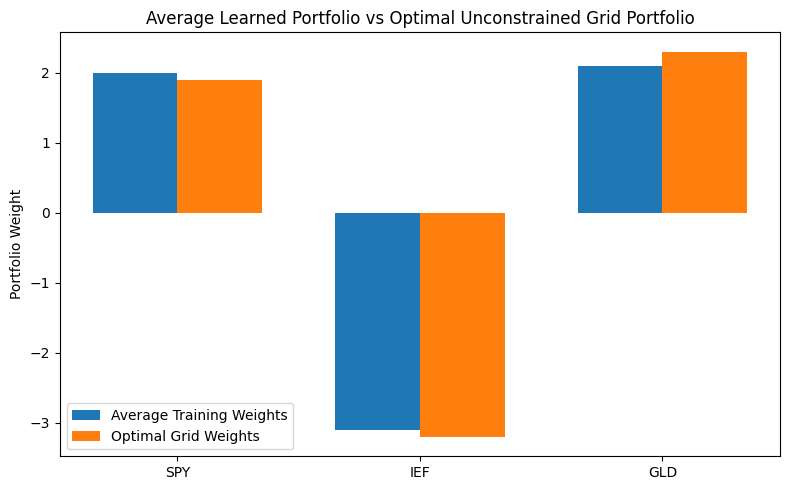

Best hyperparameters:
alpha        0.01
beta        0.002
discount      0.9
seed          123
Name: 16, dtype: object

Average training weights:
{'SPY': np.float64(1.9989), 'IEF': np.float64(-3.0989), 'GLD': np.float64(2.0999)}

Optimal grid weights:
{'SPY': np.float64(1.9), 'IEF': np.float64(-3.2), 'GLD': np.float64(2.3)}


In [49]:
# ---------------------------------------------------------
# PLOT: AVG TRAINING WEIGHTS vs OPTIMAL GRID WEIGHTS
# ---------------------------------------------------------
best_row = results_df.sort_values(
    by=["utility_gap_avg_training_to_grid", "distance_avg_training_to_grid"],
    ascending=[True, True]
).iloc[0]

learned_weights = np.array([
    best_row["avg_train_w1"],
    best_row["avg_train_w2"],
    best_row["avg_train_w3"]
], dtype=float)

optimal_weights = np.array(benchmarks["grid_weights"], dtype=float)

labels = asset_names if "asset_names" in globals() else ["SPY", "IEF", "GLD"]
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, learned_weights, width, label="Average Training Weights")
ax.bar(x + width/2, optimal_weights, width, label="Optimal Grid Weights")

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Portfolio Weight")
ax.set_title("Average Learned Portfolio vs Optimal Unconstrained Grid Portfolio")
ax.legend()

plt.tight_layout()
plt.show()

print("Best hyperparameters:")
print(best_row[["alpha", "beta", "discount", "seed"]])

print("\nAverage training weights:")
print(dict(zip(labels, learned_weights.round(4))))

print("\nOptimal grid weights:")
print(dict(zip(labels, optimal_weights.round(4))))


In [50]:
# ---------------------------------------------------------
# INSPECT FINAL GREEDY vs AVG TRAINING vs CONTINUOUS BENCHMARK
# ---------------------------------------------------------
best_row = results_df.sort_values(
    by=["utility_gap_to_grid", "distance_to_grid_benchmark"],
    ascending=[True, True]
).iloc[0]
print("Convergence iteration:", best_row["convergence_iter"])
print("Final greedy weights:")
print(best_row[["w1", "w2", "w3"]])

print("\nAverage training weights:")
print(best_row[["avg_train_w1", "avg_train_w2", "avg_train_w3"]])

print("\nOptimal grid weights:")
print(benchmarks["grid_weights"])

print("\nContinuous unconstrained benchmark weights:")
print(benchmarks["continuous_weights"])


Convergence iteration: 5000
Final greedy weights:
w1    2.0
w2   -3.1
w3    2.1
Name: 16, dtype: object

Average training weights:
avg_train_w1     1.9989
avg_train_w2   -3.09885
avg_train_w3    2.09995
Name: 16, dtype: object

Optimal grid weights:
[ 1.9 -3.2  2.3]

Continuous unconstrained benchmark weights:
[ 1.88578251 -3.23121701  2.3454345 ]


Convergence iteration: 5000


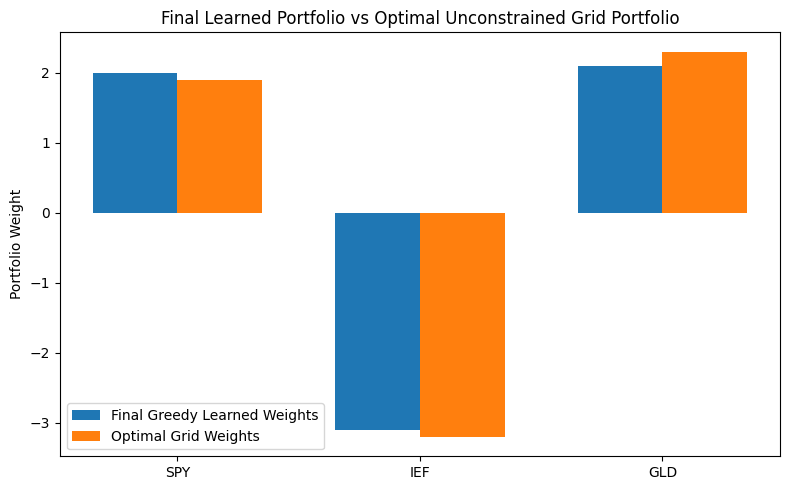

Best hyperparameters:
alpha        0.01
beta        0.002
discount      0.9
seed          123
Name: 16, dtype: object

Final greedy learned weights: [ 2.  -3.1  2.1]
Optimal grid weights: [ 1.9 -3.2  2.3]


In [51]:
# ---------------------------------------------------------
# PLOT: FINAL GREEDY LEARNED WEIGHTS vs OPTIMAL GRID WEIGHTS
# ---------------------------------------------------------
best_row = results_df.sort_values(
    by=["utility_gap_to_grid", "distance_to_grid_benchmark"],
    ascending=[True, True]
).iloc[0]
print("Convergence iteration:", best_row["convergence_iter"])
learned_weights = np.array([
    best_row["w1"],
    best_row["w2"],
    best_row["w3"]
], dtype=float)

optimal_weights = np.array(benchmarks["grid_weights"], dtype=float)

labels = asset_names if "asset_names" in globals() else ["SPY", "IEF", "GLD"]
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, learned_weights, width, label="Final Greedy Learned Weights")
ax.bar(x + width/2, optimal_weights, width, label="Optimal Grid Weights")

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Portfolio Weight")
ax.set_title("Final Learned Portfolio vs Optimal Unconstrained Grid Portfolio")
ax.legend()

plt.tight_layout()
plt.show()

print("Best hyperparameters:")
print(best_row[["alpha", "beta", "discount", "seed"]])

print("\nFinal greedy learned weights:", learned_weights)
print("Optimal grid weights:", optimal_weights)


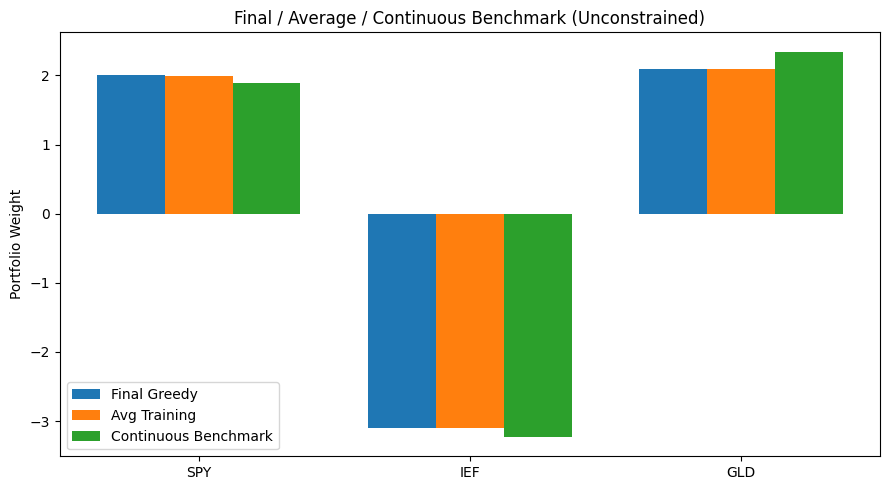

In [52]:
# ---------------------------------------------------------
# PLOT: FINAL GREEDY vs AVG TRAINING vs CONTINUOUS BENCHMARK
# ---------------------------------------------------------
best_row = results_df.sort_values(
    by=["utility_gap_to_grid", "distance_to_grid_benchmark"],
    ascending=[True, True]
).iloc[0]

final_weights = np.array([
    best_row["w1"],
    best_row["w2"],
    best_row["w3"]
], dtype=float)

avg_weights = np.array([
    best_row["avg_train_w1"],
    best_row["avg_train_w2"],
    best_row["avg_train_w3"]
], dtype=float)

continuous_weights = np.array(benchmarks["continuous_weights"], dtype=float)
labels = asset_names if "asset_names" in globals() else ["SPY", "IEF", "GLD"]
x = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width, final_weights, width, label="Final Greedy")
ax.bar(x, avg_weights, width, label="Avg Training")
ax.bar(x + width, continuous_weights, width, label="Continuous Benchmark")

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Portfolio Weight")
ax.set_title("Final / Average / Continuous Benchmark (Unconstrained)")
ax.legend()

plt.tight_layout()
plt.show()
